In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    'user_id': range(n),
    'group': np.random.choice(['A', 'B'], size=n),
    'converted': np.random.binomial(1, 0.12, n)  # baseline 12% conversion
})

# Slight improvement in group B
data.loc[data['group'] == 'B', 'converted'] = np.random.binomial(1, 0.15, sum(data['group'] == 'B'))

data.head()

,user_id,group,converted
0,0,A,0
1,1,B,0
2,2,A,0
3,3,A,0
4,4,A,0


In [2]:
conversion_rates = data.groupby('group')['converted'].mean()
print(conversion_rates)

group
A    0.108163
B    0.123529
Name: converted, dtype: float64


In [4]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 4.0 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 4.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 4.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 4.2 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 4.3 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 4.2 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 4.3 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 4.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 4.1 MB/s  0:00:02

   -------------------------

In [5]:
from statsmodels.stats.proportion import proportions_ztest

In [6]:
from statsmodels.stats.proportion import proportions_ztest

# conversions
conversions = data.groupby('group')['converted'].sum()

# total users
n_users = data.groupby('group')['user_id'].count()

stat, p_value = proportions_ztest(conversions, n_users)

print("Z-stat:", stat)
print("P-value:", p_value)

Z-stat: -0.7585652944772365
P-value: 0.44811264007972074


In [8]:
if p_value < 0.05:
    print("Statistically significant difference")
else:
    print("Not statistically significant")

Not statistically significant


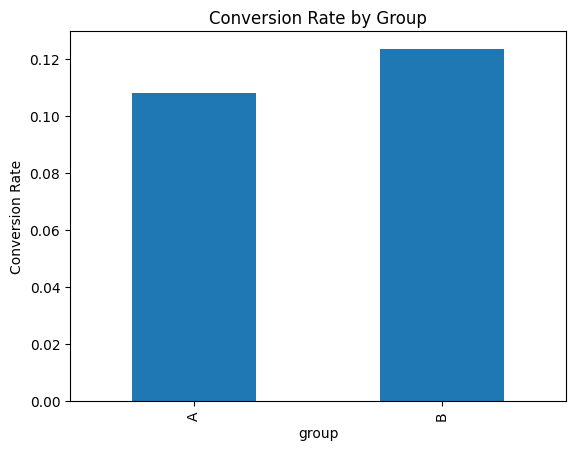

In [9]:
import matplotlib.pyplot as plt

conversion_rates.plot(kind='bar')
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()